# Day 5 — Matplotlib & Week 1 Mini-Notebook

## Step 1

In [102]:
import pandas as pd
import numpy as np
df = pd.read_csv("train.csv")

Pandas and NumPy libraries are imported and the CSV is turned into a DataFrame

In [103]:
missing = df.isnull().sum()

print(missing)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


The data cleaning process starts with listing the missing values per column.

In [104]:
df_new = df.drop(columns=["Cabin"])
print(df_new)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

The "Cabin" column is 77% empty and hence it was will dropped to improve efficiency.

In [105]:
x = df_new["Age"].median()
print("Average age:", x)
df_new["Age"]= df_new["Age"].fillna(x)
print(df_new)

Average age: 28.0
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 

All missing values in the "Age" column were filled with the median.

In [106]:
df_new = df_new.dropna(subset=["Embarked"])
print(df_new)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

Rows with missing "Embarked" values were dropped because of their minimal impact on the DataFrame.

In [107]:
zero_fare= df_new[df_new["Fare"] == 0]
print("Zero fare passengers:", len(zero_fare))

Zero fare passengers: 15


15 passengers did not pay for their tickets which share a common ticket code "LINE". They were kept because they represent real valid data and excluding them only changes the mean slightly.

In [108]:
 mean_with_zero = df["Fare"].mean()
 print("The mean including 0 Fares:", mean_with_zero)
 mean = df.loc[df["Fare"]>0, "Fare"].mean()
 print("The mean excluding 0 Fares:",mean)

The mean including 0 Fares: 32.204207968574636
The mean excluding 0 Fares: 32.75564988584475


## Step 2:

In [109]:
sibsp = df_new["SibSp"].to_numpy()
parch = df_new["Parch"].to_numpy()
age = df_new["Age"].to_numpy()
fare = df_new["Fare"].to_numpy()

family = sibsp + parch + 1
df_new["family_size"] = family

x = df_new["family_size"]
print(x)
 

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 889, dtype: int64


"Sibsp" and "Parch" columns were utilized to count family sizes of passengers.

In [110]:
age_group = np.where(age<18, "Child", np.where(age<20,"Teen", np.where( age<60, "Adult","Senior")))
df_new["age_group"] = age_group
df_new["age_group"].value_counts()

age_group
Adult     700
Child     113
Teen       51
Senior     25
Name: count, dtype: int64

"Age" column was used to sort passengers into different age groups : Child, Teen, Adult, Senior

In [111]:
mean_age = np.mean(age)
median_age = np.median(age)
std_age = np.std(age)

print("Mean age:", mean_age)
print("Median age:", median_age)
print("Standard deviation of age:", std_age)

Mean age: 29.315151856017994
Median age: 28.0
Standard deviation of age: 12.977627127265219


The mean, median and standard deviation values of "Age" were derived using NumPy functions.

In [112]:
fare_25 = np.percentile(fare, 25)
fare_75 = np.percentile(fare,75)

iqr = fare_75 - fare_25

print("25th percentile Fare:", fare_25)
print("75th percentile Fare:", fare_75)
print("Interquartile Range:", iqr)

25th percentile Fare: 7.8958
75th percentile Fare: 31.0
Interquartile Range: 23.1042


25% of the passengers paid less than 7.89 and 75% paid less than 31.
The IQR describes how spread out the middle values are and any Fares higher/lower this range( typically > 1.5 x IQR) are consideres outliers.

In [113]:
print("Minimum Fare:", np.min(fare))
print("Maximum Fare:", np.max(fare))

Minimum Fare: 0.0
Maximum Fare: 512.3292


## Step 3:

In [114]:
import matplotlib.pyplot as plt
import matplotlib.colors as ListedColormap

Matplotlib library imported.

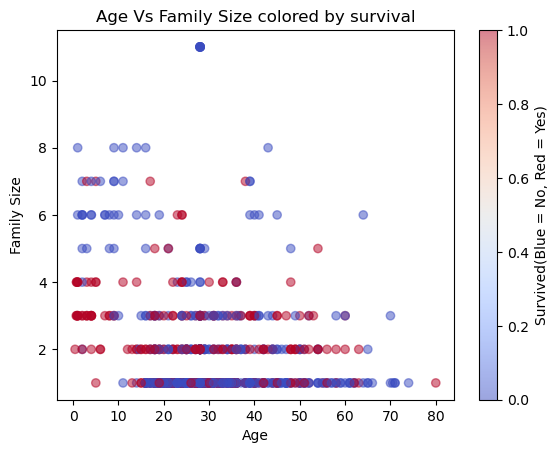

In [115]:
x = np.array(age)
y = np.array(family)
survived= df_new["Survived"].to_numpy()

plt.scatter(x,y, c=survived, cmap="coolwarm", alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Family Size")
plt.title("Age Vs Family Size colored by survival")
plt.colorbar(label= "Survived(Blue = No, Red = Yes)")
plt.show()


- This Scatter plot is to answer the question "Do younger passengers travel with larger families while older passengers travel with smaller families or solo?" in addition to  demonstrating those passengers who survived by color.

- Blue: did not survive/
Red: Survived

- Observations: Those who travel with large families and solo travelers showed a lower survival rate while others traveling with smaller families and younger passengers had a higher survival rate.

In [116]:
gender_based = df_new["Sex"].value_counts()
print(gender_based)

Sex
male      577
female    312
Name: count, dtype: int64


Number of male passengers is almost twice the number of female passengers.

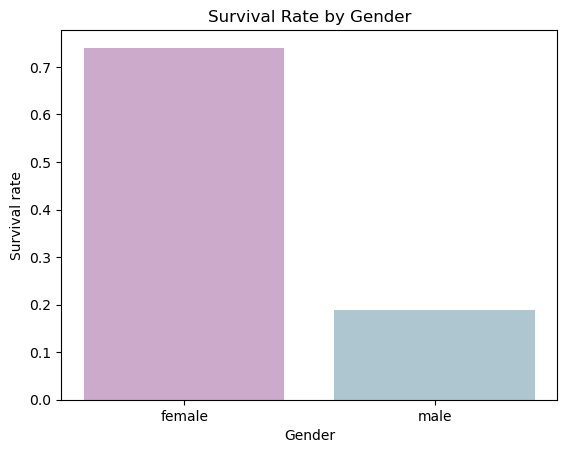

In [117]:
gender_based_survival = df_new.groupby("Sex")["Survived"].mean() 
plt.bar(gender_based_survival.index, gender_based_survival.values, color=["#CBAACB", "#AEC6CF"])
plt.xlabel("Gender")
plt.ylabel("Survival rate")
plt.title("Survival Rate by Gender")
plt.show()

- The bar chart describes survival rate by gender.
- Observations: Female passengers clearly show a higher survuval rate in comparison to male passengers, reaching approxiamtely 75% and 20% respectively despite males outnumbering females aboard.

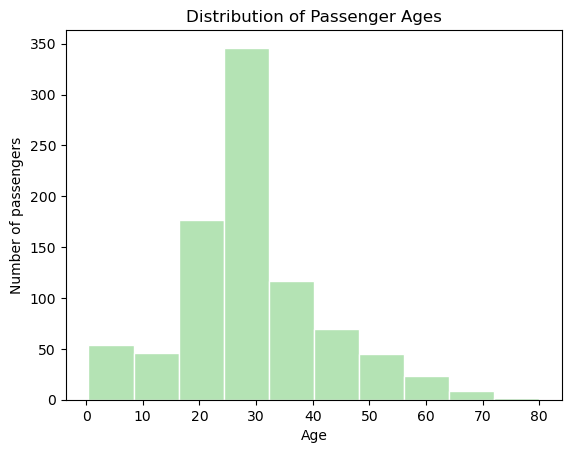

In [118]:
plt.hist(age, bins=10, color="#B4E3B4", edgecolor="white")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.title("Distribution of Passenger Ages")
plt.show()

* Majority of the passengers are younger than 35 years of age. consequently the chart is right skewed.
* The largest age groups are (mid 20s-early 30s) and (mid teens- mid 20s) comprising almost 350 and 160 of the train passengers.
* Those older than 55 years are less than 50 passengers in total.

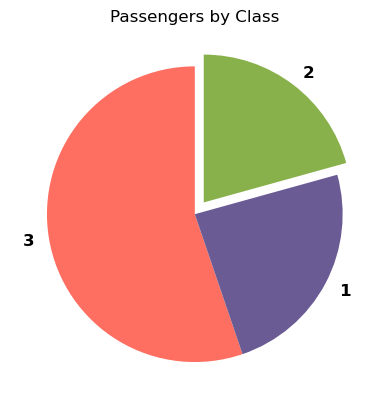

In [119]:
explode =[ 0,0,0.1]
colors= ["#FF6F61", "#6B5B95", "#88B04B"]
mylabels = ["3", "1", "2"]

plt.pie(df_new["Pclass"].value_counts(), labels=mylabels, colors = colors, explode = explode, startangle=90, textprops={"fontsize": 12, "fontweight": "bold"} )
plt.title("Passengers by Class")
plt.show()

* More than 5% of the passengers were in 3rd class.
* startangle : to start the slices at a 90 degrees angle.
* fontweight: to make the labels bold and grab the reader's attention.
* explode: to pop one slice out.

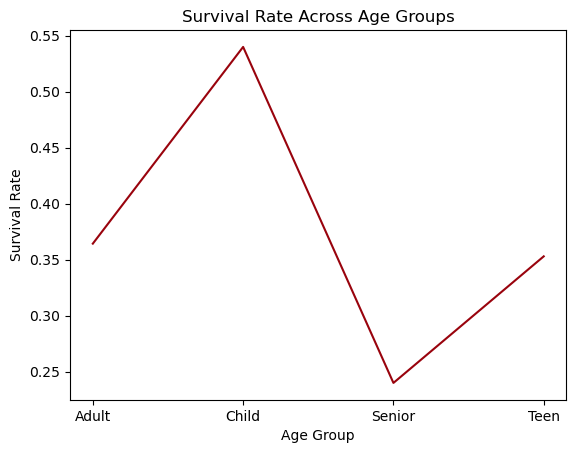

In [121]:
order = ["Child", "Teen", "Adult", "Senior"]
survival_byage = df_new.groupby("age_group")["Survived"].mean()

plt.plot( survival_byage.index, survival_byage.values, color ="#99030d")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate Across Age Groups")
plt.show()

Children show the highest survival rate of around 0.54 while Seniors show the lowest survival rate of approximately 0.23.